# Notebook 03 — Model A vs Model B


 Goal
 ----
 Compare the optimal quotes produced by the two single-asset formulations
 introduced in the paper:

   - Model A: CARA utility on terminal wealth
   - Model B: mean-variance criterion with running inventory penalty

 In both cases, the HJB problem reduces to the same tridiagonal ODE system
 (Eq. 3.9), with one key difference:

   - Model A: xi = gamma
   - Model B: xi = 0

 Paper figures reproduced:
   - Figures 8–9  : IG, Model A vs Model B
   - Figures 15–16: HY, Model A vs Model B

**Main question :** How different are the optimal quotes produced by the two models in practice?

## 1. How $\xi$ enters the equations

Both models reduce to the **same** ODE (Eq. 3.9):

$$\partial_t \theta + \tfrac{1}{2}\gamma\sigma^2 q^2 - \mathbb{1}_{q<Q}\,H_\xi\!\left(\frac{\theta(t,q) - \theta(t,q+\Delta)}{\Delta}\right) - \mathbb{1}_{q>-Q}\,H_\xi\!\left(\frac{\theta(t,q) - \theta(t,q-\Delta)}{\Delta}\right) = 0$$

The parameter $\xi$ only affects two things:

- The Hamiltonian $H_\xi$ (after Eq. 3.9)

$$H_\xi(p) = \frac{A\Delta}{k}\,C_\xi\,e^{-kp}$$

The coefficient $C_\xi$ changes:

| | $C_\xi$ | Numerical value (IG) |
|---|---|---|
| **Model A** ($\xi = \gamma$) | $\left(1 + \frac{\gamma\Delta}{k}\right)^{-(k/(\gamma\Delta)+1)}$ | $C_{3000} \approx$ very small |
| **Model B** ($\xi = 0$) | $e^{-1} \approx 0.3679$ | $0.3679$ |

- The quote extraction formula $\tilde{\delta}^*$ (Eqs. 3.14 / 3.16)

$$\tilde{\delta}^*_\xi(p) = \begin{cases} p + \frac{1}{\xi\Delta}\ln\!\left(1 + \frac{\xi\Delta}{k}\right) & \xi > 0 \quad \text{(Model A)} \\ p + \frac{1}{k} & \xi = 0 \quad \text{(Model B)} \end{cases}$$

So the **static half-spread** differs:
- Model A: $\delta_{\text{static}} = \frac{1}{\gamma\Delta}\ln(1 + \gamma\Delta/k)$
- Model B: $\delta_{\text{static}} = 1/k$

Despite these differences, the paper shows numerically that the resulting quotes are nearly identical.


In both Model A and Model B, the original market-making problem starts from a 4-dimensional HJB equation in (t,x,q,S), but Theorem 3.2 and Theorem 3.3 reduce the problem to a tridiagonal system of nonlinear ODEs in θ(t,q). The two systems are structurally identical and differ only through the parameter  ξ=γ in Model A and ξ=0 in Model B. The paper further explains that ξ can be interpreted as a form of risk aversion to non-execution risk only.

## 2. Setup

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import time
from pathlib import Path

import sys
sys.path.append(str(Path().resolve().parents[0]))

from market_making.params.assets import IG, HY, GAMMA, T
from market_making.core.solver_1d import solve_general, solve_model_a, solve_model_b
from market_making.core.intensity import C_coeff, delta_star

plt.style.use("seaborn-v0_8")
%matplotlib inline

## 3. Parameters

Same IG / HY parameters as Notebooks 01–02. The only change is $\xi$:
- **Model A**: $\xi = \gamma = 6 \times 10^{-5}$
- **Model B**: $\xi = 0$

Let's compute the key derived quantities for both models to see how much they actually differ.


In [4]:
def model_summary(params, gamma):
    xD_a = gamma * params["Delta"]
    C_a = C_coeff(xD_a, params["k"])
    C_b = C_coeff(0.0, params["k"])

    d_static_a = (1.0 / xD_a) * np.log(1.0 + xD_a / params["k"])
    d_static_b = 1.0 / params["k"]

    return {
        "xiDelta_A": xD_a,
        "xiDelta_B": 0.0,
        "C_A": C_a,
        "C_B": C_b,
        "delta_static_A": d_static_a,
        "delta_static_B": d_static_b,
        "rel_diff_delta_static": abs(d_static_a - d_static_b) / abs(d_static_a),
        "gammaDelta_over_k": xD_a / params["k"],
        "C_ratio_A_over_B": C_a / C_b,
        "C_ratio_1st_order": np.exp(-xD_a / (2.0 * params["k"])),
    }

summary_ig = model_summary(IG, GAMMA)
summary_hy = model_summary(HY, GAMMA)

In [5]:
print(f"{'Quantity':<28s} {'IG (A)':>14s} {'IG (B)':>14s} {'HY (A)':>14s} {'HY (B)':>14s}")
print("─" * 88)

rows = [
    ("ξΔ", summary_ig["xiDelta_A"], summary_ig["xiDelta_B"], summary_hy["xiDelta_A"], summary_hy["xiDelta_B"]),
    ("C_ξ", summary_ig["C_A"], summary_ig["C_B"], summary_hy["C_A"], summary_hy["C_B"]),
    ("δ_static", summary_ig["delta_static_A"], summary_ig["delta_static_B"],
                 summary_hy["delta_static_A"], summary_hy["delta_static_B"]),
]

for name, a1, b1, a2, b2 in rows:
    print(f"{name:<28s} {a1:>14.6e} {b1:>14.6e} {a2:>14.6e} {b2:>14.6e}")

print("─" * 88)
print(f"IG relative diff in δ_static: {summary_ig['rel_diff_delta_static']:.2%}")
print(f"HY relative diff in δ_static: {summary_hy['rel_diff_delta_static']:.2%}")

Quantity                             IG (A)         IG (B)         HY (A)         HY (B)
────────────────────────────────────────────────────────────────────────────────────────
ξΔ                             3.000000e+03   0.000000e+00   6.000000e+02   0.000000e+00
C_ξ                            3.397741e-01   3.678794e-01   3.489096e-01   3.678794e-01
δ_static                       5.164948e-05   5.586592e-05   1.734666e-04   1.828154e-04
────────────────────────────────────────────────────────────────────────────────────────
IG relative diff in δ_static: 8.16%
HY relative diff in δ_static: 5.39%


Even though Model A and Model B differ conceptually, the key derived quantities entering the quote formulas remain numerically close enough that the final optimal quotes are almost indistinguishable in the IG and HY calibrations considered in the paper. This is exactly the empirical point illustrated by Figures 8–9 and 15–16.

## 4. Solve the ODE for both models (Eq. 3.9)

We run `solve_general` four times: IG × {A, B} and HY × {A, B}.

Both use the **same Newton solver** (implicit Euler + Newton iteration). The only parameter that changes between Model A and Model B is the value of `xi` passed to the solver:
- `xi=GAMMA` → Model A ($\xi = \gamma$, Theorem 3.2)
- `xi=0.0` → Model B ($\xi = 0$, Theorem 3.3)


In [8]:
N_T = 7200

# IG
t0 = time.time()
sol_ig_a = solve_model_a(IG, GAMMA, T, N_t=N_T)
t1 = time.time()

sol_ig_b = solve_model_b(IG, GAMMA, T, N_t=N_T)
t2 = time.time()

# HY
sol_hy_a = solve_model_a(HY, GAMMA, T, N_t=N_T)
t3 = time.time()

sol_hy_b = solve_model_b(HY, GAMMA, T, N_t=N_T)
t4 = time.time()

print(f"IG Model A solved in {t1 - t0:.2f}s")
print(f"IG Model B solved in {t2 - t1:.2f}s")
print(f"HY Model A solved in {t3 - t2:.2f}s")
print(f"HY Model B solved in {t4 - t3:.2f}s")

IG Model A solved in 0.07s
IG Model B solved in 3.49s
HY Model A solved in 0.04s
HY Model B solved in 3.45s


## 5. Figures 8–9 (IG) and 15–16 (HY) — Model A vs Model B

**Paper reference** (p. 35, IG):
> *"We see in Figures 8 and 9 that the differences between the two models is in fact very small. In other words, although Model B ignores part of the risk (or more precisely aversion to part of the risk), it constitutes a very interesting simplification of Model A."*

**Paper reference** (p. 38, HY):
> *"As far as the comparison between Model A and Model B are concerned, we see in Figures 15 and 16 that the differences between the two models is very small, as in the case of the IG index."*

Each figure overlays:
- **Crosses (×)**: Model A quotes ($\xi = \gamma$)
- **Circles (○)**: Model B quotes ($\xi = 0$)


In [11]:
def compare_ab(sol_a, sol_b, label, fig_nums):
    """
    Compare Model A and Model B quotes at t = 0.
    Reproduces paper figures:
      - IG: Figs 8–9
      - HY: Figs 15–16
    """
    lots = sol_a["lots"]

    db_a = sol_a["delta_bid"][0, :]
    db_b = sol_b["delta_bid"][0, :]
    da_a = sol_a["delta_ask"][0, :]
    da_b = sol_b["delta_ask"][0, :]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Bid
    ax = axes[0]
    mask = np.isfinite(db_a) & np.isfinite(db_b)
    ax.plot(lots[mask], db_a[mask], "x", ms=9, mew=2, color="C0", label="Model A (ξ = γ)")
    ax.plot(lots[mask], db_b[mask], "o", ms=7, mfc="none", mew=2, color="C1", label="Model B (ξ = 0)")
    ax.set_title(f"Fig {fig_nums[0]}: {label} — δ^bid(0, n)", fontsize=11)
    ax.set_xlabel("n (lots)")
    ax.set_ylabel("δ^bid ($/upfront)")
    ax.grid(alpha=0.3)
    ax.legend()

    # Ask
    ax = axes[1]
    mask = np.isfinite(da_a) & np.isfinite(da_b)
    ax.plot(lots[mask], da_a[mask], "x", ms=9, mew=2, color="C0", label="Model A (ξ = γ)")
    ax.plot(lots[mask], da_b[mask], "o", ms=7, mfc="none", mew=2, color="C1", label="Model B (ξ = 0)")
    ax.set_title(f"Fig {fig_nums[1]}: {label} — δ^ask(0, n)", fontsize=11)
    ax.set_xlabel("n (lots)")
    ax.set_ylabel("δ^ask ($/upfront)")
    ax.grid(alpha=0.3)
    ax.legend()

    fig.suptitle(f"Model A vs Model B — {label}", fontsize=14, y=1.02)
    fig.tight_layout()
    plt.show()

### 5.1 IG — Figures 8–9

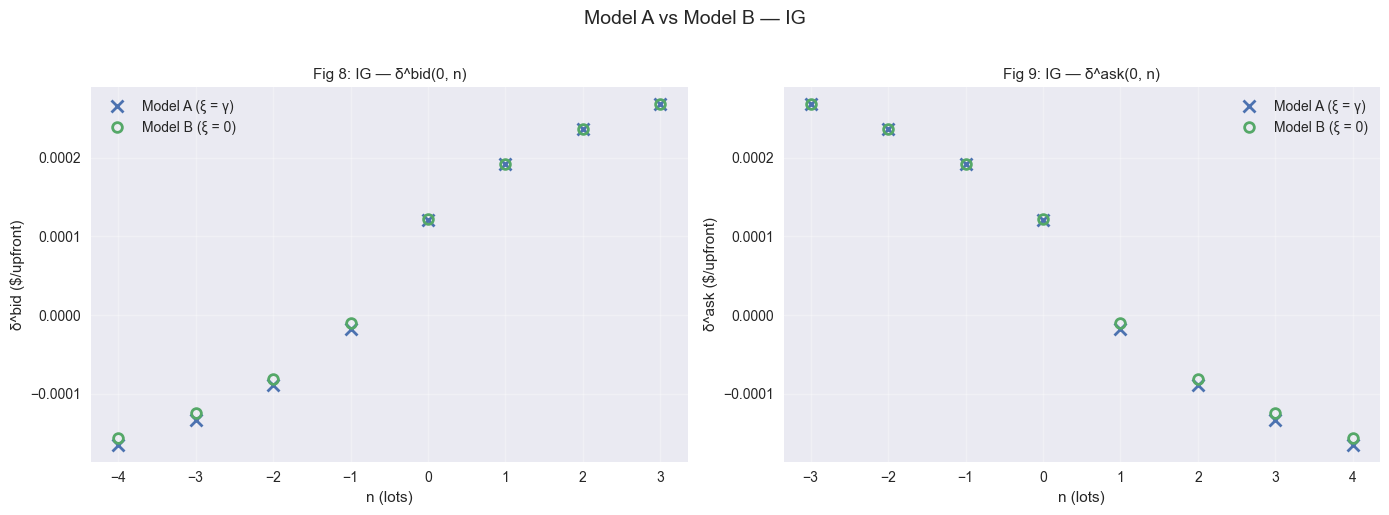

In [12]:
compare_ab(sol_ig_a, sol_ig_b, "IG", fig_nums=(8, 9))


### 5.2 HY — Figures 15–16

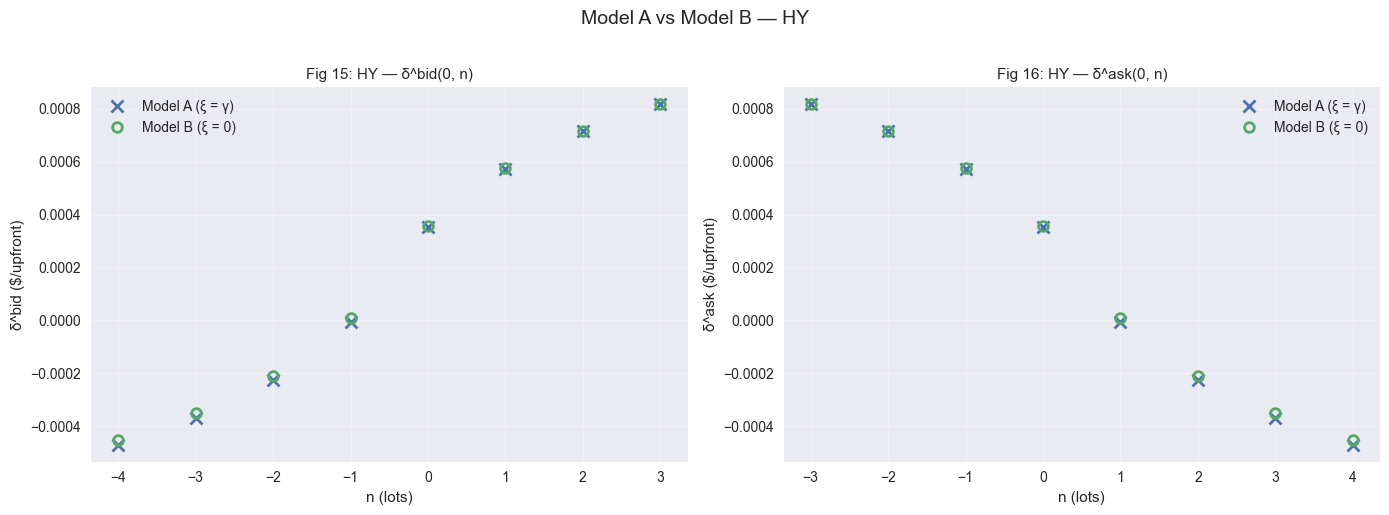

In [13]:
compare_ab(sol_hy_a, sol_hy_b, "HY", fig_nums=(15, 16))

| Paper Fig | Content | Key observation |
|-----------|---------|-----------------|
| Fig 8 | IG $\delta^b(0,n)$: A (×) vs B (○) | Nearly indistinguishable |
| Fig 9 | IG $\delta^a(0,n)$: A (×) vs B (○) | Nearly indistinguishable |
| Fig 15 | HY $\delta^b(0,n)$: A (×) vs B (○) | Nearly indistinguishable |
| Fig 16 | HY $\delta^a(0,n)$: A (×) vs B (○) | Nearly indistinguishable |

### Key result

Model B ($\xi = 0$) is an excellent approximation of Model A ($\xi = \gamma$).

**Why this matters for practitioners** (Paper §3.4):
- Model B is simpler to interpret (mean-variance, running penalty).
- Model B is used in the Cartea–Jaimungal framework and most applied work.
- The paper validates it as a *"very interesting simplification"* (p. 35).


The overlays reproduce the qualitative message of Figures 8–9 and 15–16 of the paper: the quotes produced by Model A and Model B are almost indistinguishable, both for the IG index and for the HY index. This confirms that, under the Section 6 calibration, ignoring non-execution-risk aversion has only a limited quantitative effect on the optimal quotes.

## A.2 Quantitative error table — A vs B

Pointwise comparison across all valid inventory levels, for bid, ask, spread, and skew.


In [14]:
def full_error_table(sol_a, sol_b, label):
    print(f"\n=== {label} ===")
    print(f"{'Quantity':<18s} {'max|A-B|':>14s} {'mean|A-B|':>14s}")
    print("─" * 50)

    comparisons = [
        ("δ^bid",  sol_a["delta_bid"][0, :], sol_b["delta_bid"][0, :]),
        ("δ^ask",  sol_a["delta_ask"][0, :], sol_b["delta_ask"][0, :]),
        ("Spread", sol_a["delta_bid"][0, :] + sol_a["delta_ask"][0, :],
                   sol_b["delta_bid"][0, :] + sol_b["delta_ask"][0, :]),
        ("Skew",   sol_a["delta_bid"][0, :] - sol_a["delta_ask"][0, :],
                   sol_b["delta_bid"][0, :] - sol_b["delta_ask"][0, :]),
    ]

    for name, arr_a, arr_b in comparisons:
        mask = np.isfinite(arr_a) & np.isfinite(arr_b)
        abs_err = np.abs(arr_a[mask] - arr_b[mask])
        print(f"{name:<18s} {abs_err.max():>14.4e} {abs_err.mean():>14.4e}")

In [15]:
full_error_table(sol_ig_a, sol_ig_b, "IG")
full_error_table(sol_hy_a, sol_hy_b, "HY")


=== IG ===
Quantity                 max|A-B|      mean|A-B|
──────────────────────────────────────────────────
δ^bid                  8.5554e-06     4.2604e-06
δ^ask                  8.5554e-06     4.2604e-06
Spread                 8.3634e-06     7.1932e-06
Skew                   8.6085e-06     6.9451e-06

=== HY ===
Quantity                 max|A-B|      mean|A-B|
──────────────────────────────────────────────────
δ^bid                  1.8663e-05     9.3487e-06
δ^ask                  1.8663e-05     9.3487e-06
Spread                 1.8456e-05     1.6036e-05
Skew                   1.8388e-05     1.4365e-05


The pointwise errors are small in absolute value for bid, ask, spread, and skew. This strengthens the paper’s conclusion: Model B is not only conceptually simpler, it is also numerically very close to Model A in the calibrations considered here.

## A.3 Why are the two models so close?

The difference between Model A and B lives entirely in $C_\xi$:

$$\frac{C_{\gamma\Delta}}{C_0} = \frac{\left(1 + \frac{\gamma\Delta}{k}\right)^{-(k/(\gamma\Delta)+1)}}{e^{-1}}$$

When $\gamma\Delta / k$ is small, we can expand:

$$\ln C_{\gamma\Delta} = -\left(\frac{k}{\gamma\Delta} + 1\right)\ln\!\left(1 + \frac{\gamma\Delta}{k}\right) \approx -1 - \frac{\gamma\Delta}{2k} + O\!\left(\frac{\gamma\Delta}{k}\right)^2$$

So $C_{\gamma\Delta} \approx e^{-1} \cdot e^{-\gamma\Delta/(2k)} \approx C_0$ when $\gamma\Delta \ll k$.

Let's check this ratio for our parameters.


In [16]:
for name, params, summary in [
    ("IG", IG, summary_ig),
    ("HY", HY, summary_hy),
]:
    print(
        f"{name}: γΔ/k = {summary['gammaDelta_over_k']:.4f}   "
        f"C_A/C_B = {summary['C_ratio_A_over_B']:.6f}   "
        f"1st-order approx = {summary['C_ratio_1st_order']:.6f}"
    )

IG: γΔ/k = 0.1676   C_A/C_B = 0.923602   1st-order approx = 0.919616
HY: γΔ/k = 0.1097   C_A/C_B = 0.948434   1st-order approx = 0.946632


Both ratios ≈ 1 → explains why quotes are nearly identical.
The difference is O(γΔ/k), which is small for both assets.

## A.4 Spread and skew — A vs B

The paper only shows bid and ask overlays (Figs 8–9, 15–16). Let's also compare spread and skew, which are the quantities practitioners actually use.


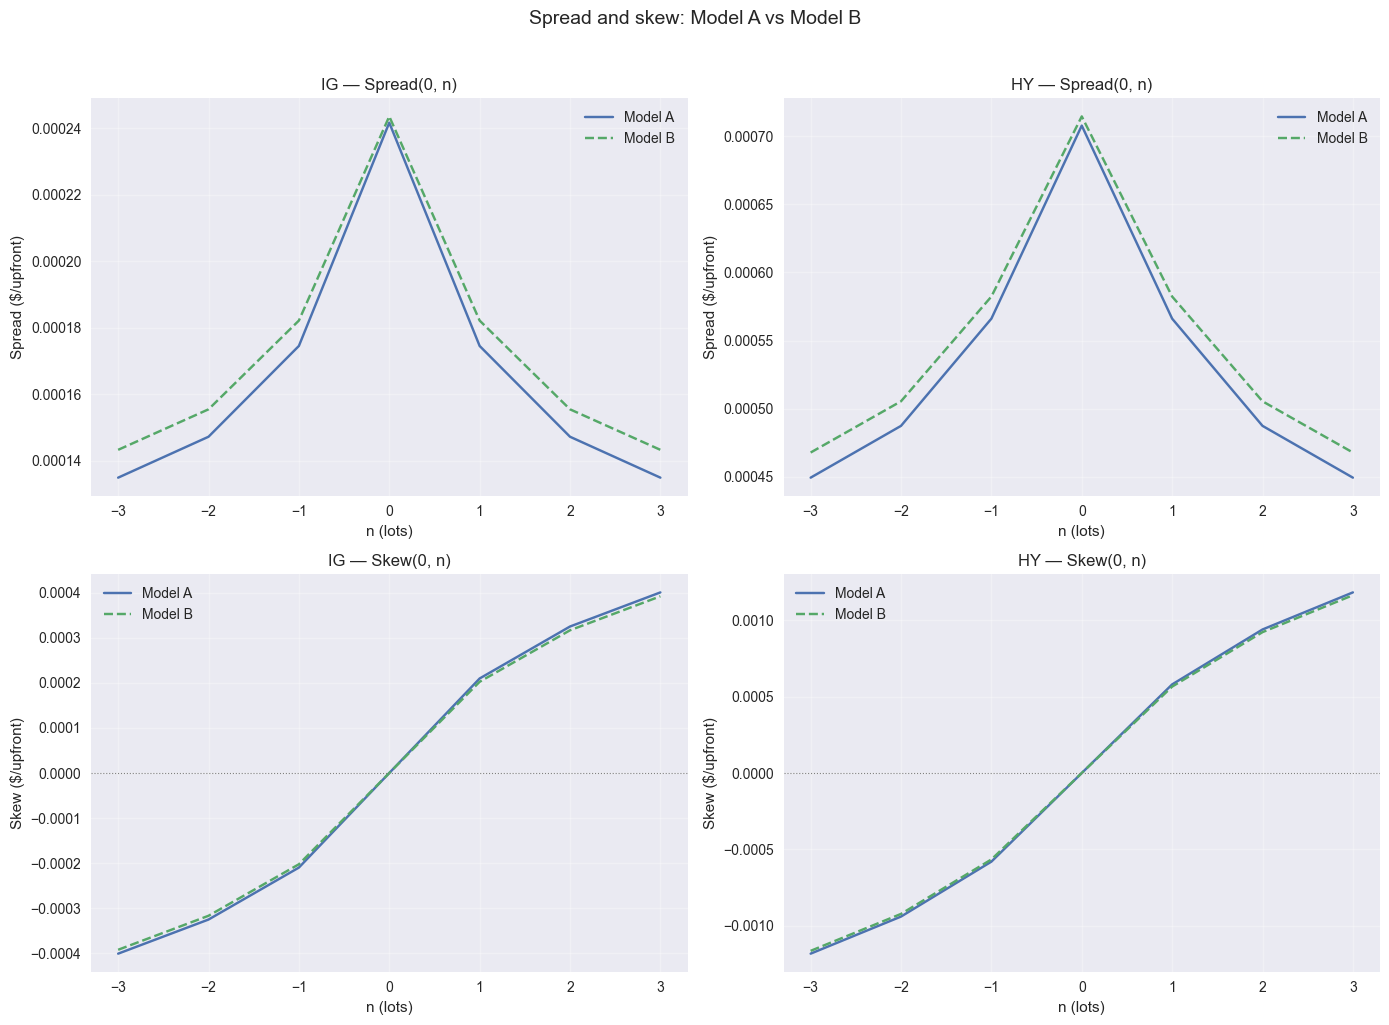

In [18]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for col, (sol_a, sol_b, name) in enumerate([
    (sol_ig_a, sol_ig_b, "IG"),
    (sol_hy_a, sol_hy_b, "HY"),
]):
    lots = sol_a["lots"]

    spread_a = sol_a["delta_bid"][0, :] + sol_a["delta_ask"][0, :]
    spread_b = sol_b["delta_bid"][0, :] + sol_b["delta_ask"][0, :]

    skew_a = sol_a["delta_bid"][0, :] - sol_a["delta_ask"][0, :]
    skew_b = sol_b["delta_bid"][0, :] - sol_b["delta_ask"][0, :]

    # Spread
    ax = axes[0, col]
    mask = np.isfinite(spread_a) & np.isfinite(spread_b)
    ax.plot(lots[mask], spread_a[mask], "x-", ms=8, label="Model A")
    ax.plot(lots[mask], spread_b[mask], "o--", ms=6, mfc="none", label="Model B")
    ax.set_title(f"{name} — Spread(0, n)")
    ax.set_xlabel("n (lots)")
    ax.set_ylabel("Spread ($/upfront)")
    ax.grid(alpha=0.3)
    ax.legend()

    # Skew
    ax = axes[1, col]
    mask = np.isfinite(skew_a) & np.isfinite(skew_b)
    ax.plot(lots[mask], skew_a[mask], "x-", ms=8, label="Model A")
    ax.plot(lots[mask], skew_b[mask], "o--", ms=6, mfc="none", label="Model B")
    ax.set_title(f"{name} — Skew(0, n)")
    ax.set_xlabel("n (lots)")
    ax.set_ylabel("Skew ($/upfront)")
    ax.axhline(0.0, color="gray", ls=":", lw=0.8)
    ax.grid(alpha=0.3)
    ax.legend()

fig.suptitle("Spread and skew: Model A vs Model B", fontsize=14, y=1.02)
fig.tight_layout()
plt.show()

## A.6 Value function $\theta(0,n)$ — A vs B

The quotes are derived from the discrete gradient of $\theta$. Let's compare $\theta$ itself to see if the functions are close or if cancellation effects make the quotes look similar.


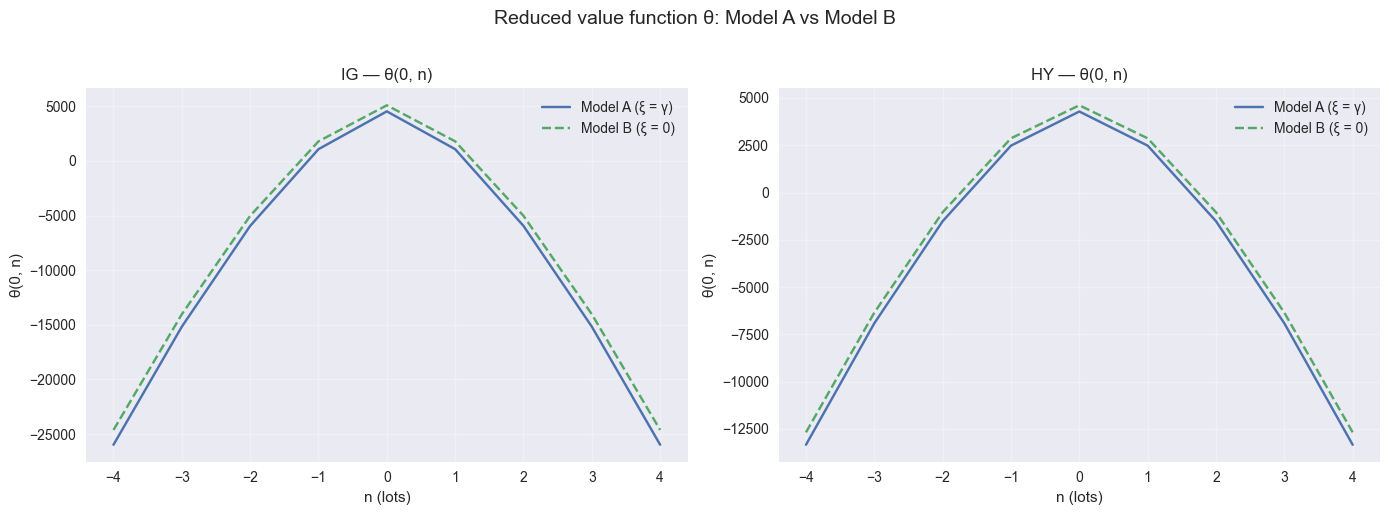

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, sol_a, sol_b, name in [
    (axes[0], sol_ig_a, sol_ig_b, "IG"),
    (axes[1], sol_hy_a, sol_hy_b, "HY"),
]:
    lots = sol_a["lots"]
    ax.plot(lots, sol_a["theta"][0, :], "x-", ms=8, label="Model A (ξ = γ)")
    ax.plot(lots, sol_b["theta"][0, :], "o--", ms=6, mfc="none", label="Model B (ξ = 0)")
    ax.set_xlabel("n (lots)")
    ax.set_ylabel("θ(0, n)")
    ax.set_title(f"{name} — θ(0, n)")
    ax.grid(alpha=0.3)
    ax.legend()

fig.suptitle("Reduced value function θ: Model A vs Model B", fontsize=14, y=1.02)
fig.tight_layout()
plt.show()

Since bid and ask quotes are extracted from discrete gradients of θ, comparing the value functions themselves helps determine whether the similarity in quotes is structural or due to cancellation effects. If the two θ-profiles are already close, then the near-equality of quotes is not accidental.

The reduced value functions are close but not identical. Therefore, the similarity of the quotes is structural rather than accidental: the discrete gradients of the two value functions remain close across the inventory grid.

Main conclusion.
For both IG and HY, Model A and Model B generate almost identical optimal quotes. This reproduces the message of Figures 8–9 and 15–16 in the paper: although Model B ignores aversion to non-execution risk, it remains a very accurate practical simplification of Model A.
Economic interpretation.
Model A is conceptually richer because risk aversion applies both to price risk and non-execution risk. Model B only penalises price risk through the running inventory term. Yet, under the calibrated single-asset parameters considered here, the quantitative effect of this extra source of aversion remains small enough that the resulting optimal quotes are nearly unchanged. 
Practical implication.
For implementation, interpretation, and computation, Model B is often attractive. The paper’s numerical evidence and our error tables support using it as a tractable proxy for Model A in many realistic situations.